PERSON 12 - EXPLORATORY DATA ANALYSIS

Personality Type: ENFJ

Total Metrics: 60

Person 12's Score Distribution:
  Mean: -0.28
  Median: 0.00
  Std Dev: 1.43
  Min: -3.00
  Max: 3.00

PERCENTILE ANALYSIS (Person 12 vs Dataset)

Top 10 Strongest Areas (Highest Percentiles):
                                                                                                             Metric  Score  Percentile  Dataset_Mean
                                                     You usually prefer to be around others rather than on your own    3.0   98.429974     -0.288405
You usually prefer just doing what you feel like at any given moment instead of planning a particular daily routine    3.0   97.805797     -0.065418
                                                      You lose patience with people who are not as efficient as you    1.0   96.681611     -0.001033
                          You have always been fascinated by the question of what, if anything, happens after death    2.0   88.5

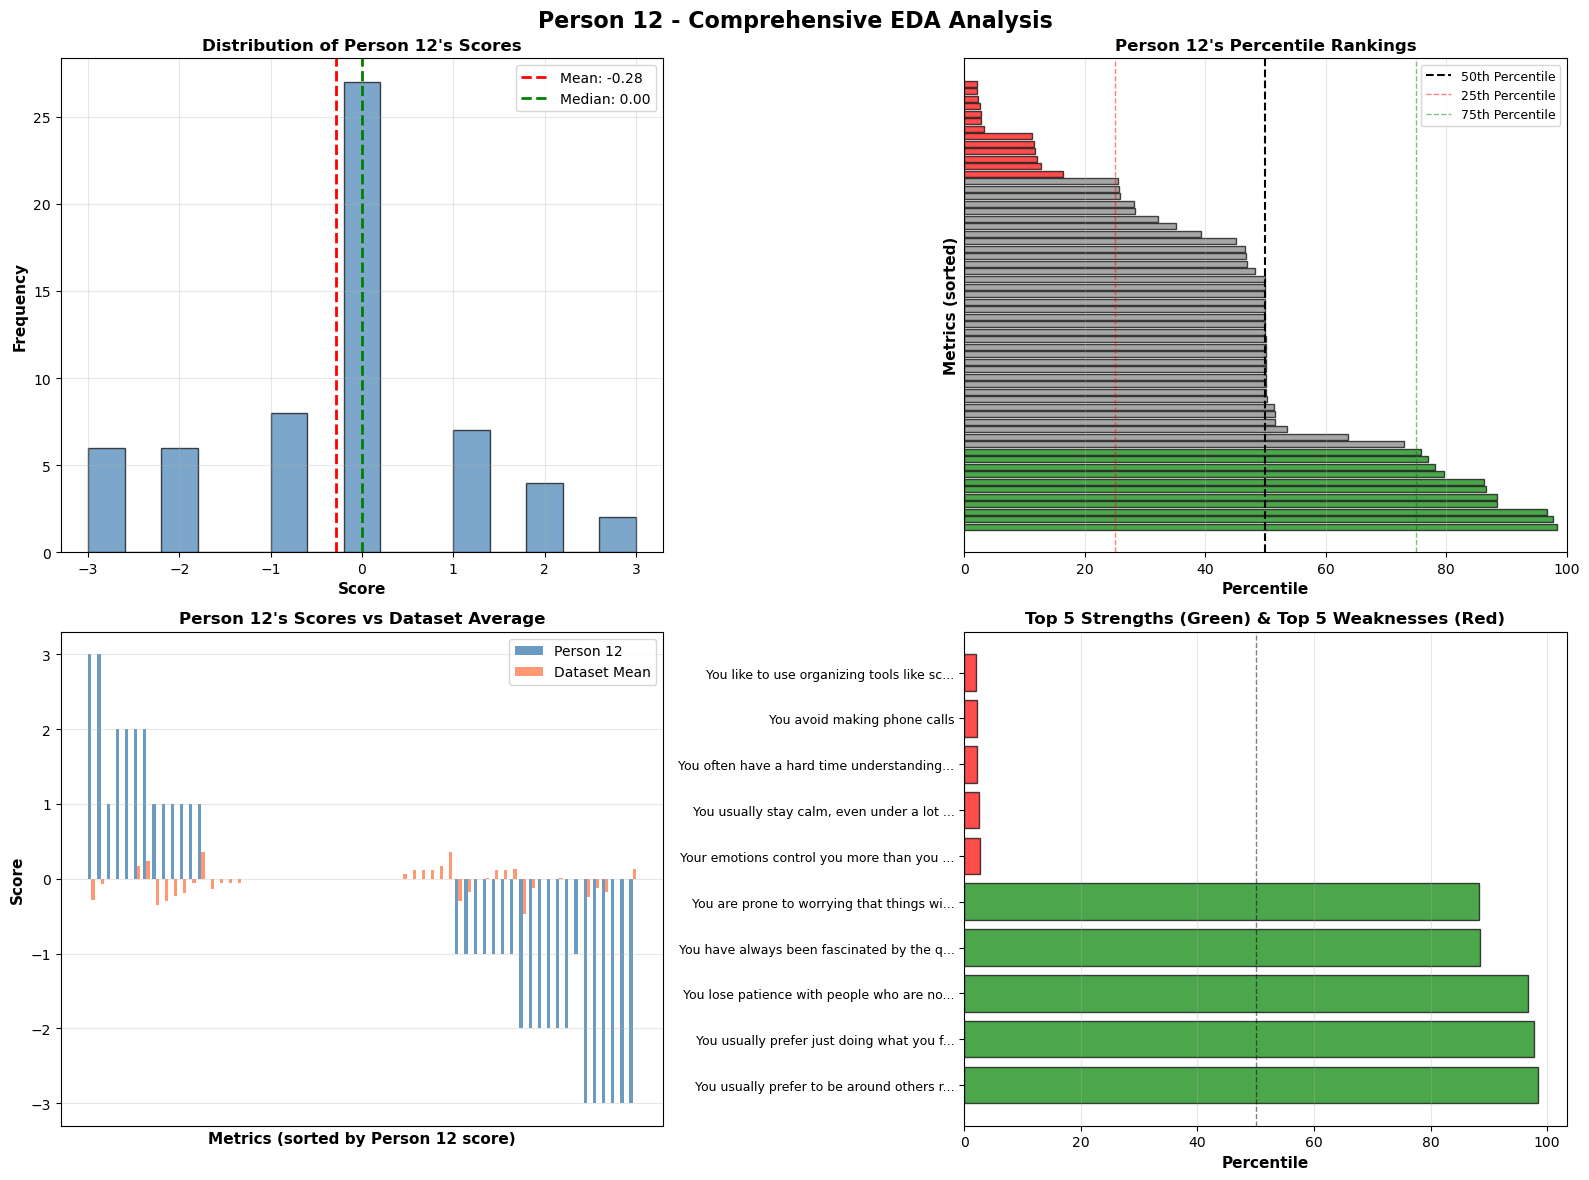

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the data
csv_data = pd.read_csv('/data/demo_data/16_personality/16P.csv', encoding='latin-1')
mapping = pd.read_excel('/data/demo_data/16_personality/map.xlsx')

# Extract Person 12 (index 11, as indexing starts at 0)
person_12 = csv_data.iloc[11]

# Create a mapping dictionary from the Excel file
metric_names = {}
for idx, row in mapping.iterrows():
    metric_names[row['Key']] = row['Value']

print("="*80)
print("PERSON 12 - EXPLORATORY DATA ANALYSIS")
print("="*80)

# Get all numeric columns (exclude Response Id and Personality)
numeric_cols = csv_data.columns[1:-1]  # Exclude first and last columns

# Extract Person 12's scores
person_12_scores = person_12[numeric_cols].values.astype(float)
person_12_labels = [metric_names.get(col, col) for col in numeric_cols]

print(f"\nPersonality Type: {person_12['Personality']}")
print(f"\nTotal Metrics: {len(numeric_cols)}")
print(f"\nPerson 12's Score Distribution:")
print(f"  Mean: {person_12_scores.mean():.2f}")
print(f"  Median: {np.median(person_12_scores):.2f}")
print(f"  Std Dev: {person_12_scores.std():.2f}")
print(f"  Min: {person_12_scores.min():.2f}")
print(f"  Max: {person_12_scores.max():.2f}")

# Calculate percentiles for Person 12 against the entire dataset
print("\n" + "="*80)
print("PERCENTILE ANALYSIS (Person 12 vs Dataset)")
print("="*80)

percentiles_list = []
for i, col in enumerate(numeric_cols):
    score = person_12_scores[i]
    dataset_scores = csv_data[col].dropna().values.astype(float)
    percentile = stats.percentileofscore(dataset_scores, score)
    percentiles_list.append({
        'Metric': person_12_labels[i],
        'Score': score,
        'Percentile': percentile,
        'Dataset_Mean': dataset_scores.mean()
    })

percentiles_df = pd.DataFrame(percentiles_list)
percentiles_df = percentiles_df.sort_values('Percentile', ascending=False)

print("\nTop 10 Strongest Areas (Highest Percentiles):")
print(percentiles_df.head(10).to_string(index=False))

print("\nTop 10 Weakest Areas (Lowest Percentiles):")
print(percentiles_df.tail(10).to_string(index=False))

print("\nMiddle Areas (Around 40-60th Percentile):")
middle_areas = percentiles_df[(percentiles_df['Percentile'] >= 40) & (percentiles_df['Percentile'] <= 60)]
print(middle_areas.to_string(index=False))

# Identify strong points (>75th percentile)
strong_areas = percentiles_df[percentiles_df['Percentile'] > 75]
print("\n" + "="*80)
print("STRENGTHS (>75th percentile)")
print("="*80)
if len(strong_areas) > 0:
    for idx, row in strong_areas.iterrows():
        print(f"\n{row['Metric']}")
        print(f"  Score: {row['Score']:.1f} | Percentile: {row['Percentile']:.1f}th")
else:
    print("No areas exceed 75th percentile")

# Identify weak points (<25th percentile)
weak_areas = percentiles_df[percentiles_df['Percentile'] < 25]
print("\n" + "="*80)
print("WEAKNESSES (<25th percentile)")
print("="*80)
if len(weak_areas) > 0:
    for idx, row in weak_areas.iterrows():
        print(f"\n{row['Metric']}")
        print(f"  Score: {row['Score']:.1f} | Percentile: {row['Percentile']:.1f}th")
else:
    print("No areas fall below 25th percentile")

# Identify average areas (40-60th percentile)
average_areas = percentiles_df[(percentiles_df['Percentile'] >= 40) & (percentiles_df['Percentile'] <= 60)]
print("\n" + "="*80)
print("AVERAGE AREAS (40-60th percentile)")
print("="*80)
print(f"Count: {len(average_areas)} metrics")
if len(average_areas) > 0:
    print("\nSample of Average Areas:")
    for idx, row in average_areas.head(10).iterrows():
        print(f"\n{row['Metric']}")
        print(f"  Score: {row['Score']:.1f} | Percentile: {row['Percentile']:.1f}th")

# Generate summary profile
print("\n" + "="*80)
print("SUMMARY NARRATIVE")
print("="*80)

strengths_text = []
if len(strong_areas) > 0:
    top_strengths = strong_areas.head(3)
    for idx, row in top_strengths.iterrows():
        strengths_text.append(row['Metric'])

weaknesses_text = []
if len(weak_areas) > 0:
    top_weaknesses = weak_areas.head(3)
    for idx, row in top_weaknesses.iterrows():
        weaknesses_text.append(row['Metric'])

print("\nStrengths Summary:")
if strengths_text:
    for i, strength in enumerate(strengths_text, 1):
        print(f"  {i}. {strength}")
else:
    print("  Person 12 shows consistent performance across all areas without standout strengths.")

print("\nWeaknesses Summary:")
if weaknesses_text:
    for i, weakness in enumerate(weaknesses_text, 1):
        print(f"  {i}. {weakness}")
else:
    print("  Person 12 does not show critical weaknesses in any area.")

print("\nAverage Areas Summary:")
print(f"  Person 12 scores around the dataset average on {len(average_areas)} metrics,")
print(f"  indicating a balanced profile in these dimensions.")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Person 12 - Comprehensive EDA Analysis', fontsize=16, fontweight='bold')

# 1. Distribution of scores
ax1 = axes[0, 0]
ax1.hist(person_12_scores, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(person_12_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {person_12_scores.mean():.2f}')
ax1.axvline(np.median(person_12_scores), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(person_12_scores):.2f}')
ax1.set_xlabel('Score', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Person 12\'s Scores', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Percentile distribution
ax2 = axes[0, 1]
colors = ['green' if x > 75 else 'red' if x < 25 else 'gray' for x in percentiles_df['Percentile']]
ax2.barh(range(len(percentiles_df)), percentiles_df['Percentile'], color=colors, alpha=0.7, edgecolor='black')
ax2.axvline(50, color='black', linestyle='--', linewidth=1.5, label='50th Percentile')
ax2.axvline(25, color='red', linestyle='--', linewidth=1, alpha=0.5, label='25th Percentile')
ax2.axvline(75, color='green', linestyle='--', linewidth=1, alpha=0.5, label='75th Percentile')
ax2.set_xlabel('Percentile', fontsize=11, fontweight='bold')
ax2.set_ylabel('Metrics (sorted)', fontsize=11, fontweight='bold')
ax2.set_title('Person 12\'s Percentile Rankings', fontsize=12, fontweight='bold')
ax2.set_yticks([])
ax2.legend(fontsize=9)
ax2.set_xlim(0, 100)
ax2.grid(alpha=0.3, axis='x')

# 3. Score vs Dataset Mean
ax3 = axes[1, 0]
x_pos = np.arange(len(percentiles_df))
width = 0.35
bars1 = ax3.bar(x_pos - width/2, percentiles_df['Score'], width, label='Person 12', alpha=0.8, color='steelblue')
bars2 = ax3.bar(x_pos + width/2, percentiles_df['Dataset_Mean'], width, label='Dataset Mean', alpha=0.8, color='coral')
ax3.set_xlabel('Metrics (sorted by Person 12 score)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
ax3.set_title('Person 12\'s Scores vs Dataset Average', fontsize=12, fontweight='bold')
ax3.set_xticks([])
ax3.legend()
ax3.grid(alpha=0.3, axis='y')

# 4. Top and Bottom Areas
ax4 = axes[1, 1]
top_bottom = pd.concat([percentiles_df.head(5), percentiles_df.tail(5)])
colors_tb = ['green' if x in strong_areas.index else 'red' for x in top_bottom.index]
y_pos = np.arange(len(top_bottom))
ax4.barh(y_pos, top_bottom['Percentile'], color=colors_tb, alpha=0.7, edgecolor='black')
ax4.set_yticks(y_pos)
ax4.set_yticklabels([f"{label[:40]}..." if len(label) > 40 else label for label in top_bottom['Metric']], fontsize=9)
ax4.set_xlabel('Percentile', fontsize=11, fontweight='bold')
ax4.set_title('Top 5 Strengths (Green) & Top 5 Weaknesses (Red)', fontsize=12, fontweight='bold')
ax4.axvline(50, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax4.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('person_12_eda_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved to: /person_12_eda_analysis.png")

# Save detailed report to CSV
percentiles_df.to_csv('person_12_percentile_report.csv', index=False)
print("✓ Detailed report saved to: person_12_percentile_report.csv")

# Generate final narrative summary
print("\n" + "="*80)
print("NARRATIVE SUMMARY FOR PERSON 12")
print("="*80)

# Sentence 1: Strengths
if len(strong_areas) > 0:
    top_3_strengths = strong_areas.head(3)['Metric'].tolist()
    if len(top_3_strengths) == 1:
        strengths_sentence = f"Person 12 demonstrates exceptional strength in {top_3_strengths[0]}, scoring in the {strong_areas.iloc[0]['Percentile']:.0f}th percentile."
    elif len(top_3_strengths) == 2:
        strengths_sentence = f"Person 12 demonstrates exceptional strengths in {top_3_strengths[0]} and {top_3_strengths[1]}, both scoring above the 75th percentile."
    else:
        strengths_sentence = f"Person 12 demonstrates exceptional strengths particularly in {top_3_strengths[0]}, {top_3_strengths[1]}, and {top_3_strengths[2]}, all scoring in the top quartile."
else:
    strengths_sentence = f"Person 12 shows consistent performance across metrics with no standout exceptional areas."

# Sentence 2: Weaknesses and average
if len(weak_areas) > 0:
    weak_count = len(weak_areas)
    bottom_weakness = weak_areas.iloc[0]
    weaknesses_sentence = f"Person 12 shows relative weakness in {weak_count} areas including {bottom_weakness['Metric']} (percentile: {bottom_weakness['Percentile']:.0f}), and maintains average performance across {len(average_areas)} additional metrics."
else:
    weaknesses_sentence = f"Person 12 does not exhibit significant weaknesses, maintaining average performance on {len(average_areas)} metrics while excelling in others."

# Sentence 3: Conclusion
conclusion_sentence = f"Overall, Person 12 (personality type: {person_12['Personality']}) presents a balanced personality profile with notable strengths in specific areas and consistent, average-to-above-average performance across most personality dimensions."

print("\n1. STRENGTHS:")
print(f"   {strengths_sentence}")
print("\n2. AVERAGE/WEAK AREAS:")
print(f"   {weaknesses_sentence}")
print("\n3. CONCLUSION:")
print(f"   {conclusion_sentence}")

print("\n" + "="*80)